In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import warnings
warnings.filterwarnings('ignore')

# EDA

In [3]:
df=pd.read_excel("dataset.xlsx")

In [4]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [5]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [7]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [8]:
# Removing empty and Non English Reviews

In [9]:
df=df[df['body'].str.strip() != ""]

In [10]:
df =df[df['body'].str.contains(r'[a-zA-Z]', regex=True)]

In [11]:
# checking for null values
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [12]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(1437, 3)

In [14]:
df.describe()

,rating
count,1437.000000
mean,3.178149
std,1.582986
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [15]:
# cleaning Data

In [16]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 4.1 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.4 MB/s eta 0:00:03
     ---------- ----------------------------- 3.4/12.8 MB 5.1 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.8 MB 5.6 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 6.3 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 7.0 MB/s eta 0:00:01
     ------------------------------------ --- 11.8/12.8 MB 7.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.7 MB/s  0:00:02
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [17]:
import spacy
nlp = spacy.load("en_core_web_sm")
import re
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import string
from nltk.corpus import stopwords

In [18]:
import re
import nltk

# Download the stopwords resource if not already downloaded
nltk.download('stopwords')

from nltk.corpus import stopwords

# removing stop words
# Keep important negation words

custom_stopwords = set(stopwords.words('english'))
custom_stopwords = custom_stopwords - {"not","no","never","nor"}

def clean_text(text):
    text = str(text).lower()# Convert to lowercase
    text = re.sub(r'http\\S+|www\\S+', '', text) # Remove links
    text = re.sub(r'\\d+', '', text) # Remove numbers

    # SpaCy processing
    doc = nlp(text)
    tokens = [token.lemma_
        for token in doc
        if token.text not in custom_stopwords
        and not token.is_punct
        and token.is_alpha
    ]

    return " ".join(tokens)

df['clean_review'] = df['body'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))
df['word_count'].describe()

count    1437.000000
mean       28.968685
std        20.862656
min         1.000000
25%        17.000000
50%        24.000000
75%        35.000000
max       246.000000
Name: word_count, dtype: float64

In [20]:
# Bar chart

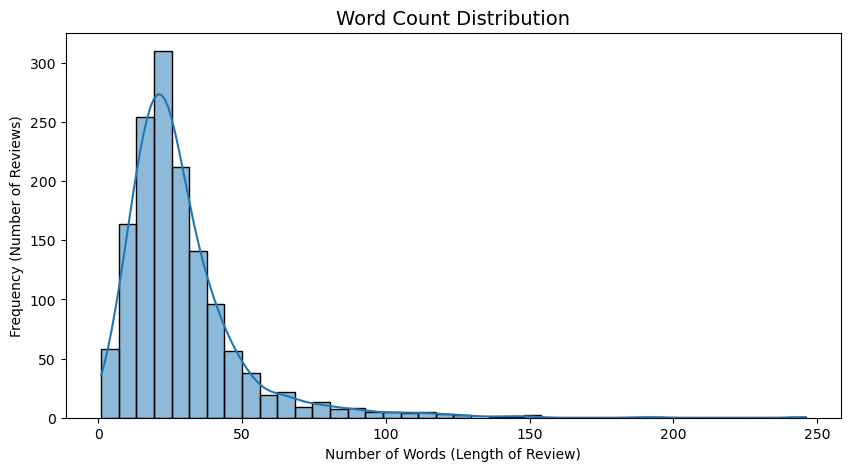

In [21]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.title("Word Count Distribution", fontsize=14)
plt.xlabel("Number of Words (Length of Review)")
plt.ylabel("Frequency (Number of Reviews)")

plt.show()

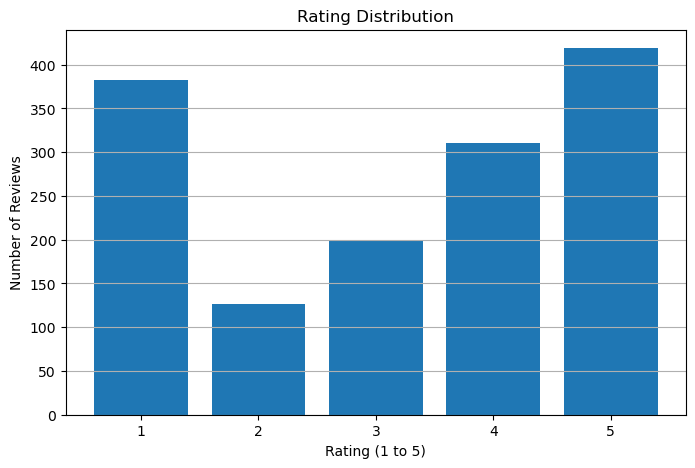

In [22]:
# Count ratings
rating_counts = df['rating'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Rating Distribution")
plt.xlabel("Rating (1 to 5)")                 # X-axis → categories
plt.ylabel("Number of Reviews")               # Y-axis → frequency
plt.xticks([1,2,3,4,5])                       # show all ratings clearly
plt.grid(axis='y')
plt.show()

In [23]:
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

In [24]:
df['sentiment'].value_counts()

sentiment
Positive    729
Negative    509
Neutral     199
Name: count, dtype: int64

In [25]:

# CLASS DISTRIBUTION
print("\nPercentage Distribution\n")
print(
    df['sentiment'].value_counts(normalize=True) * 100
)


Percentage Distribution

sentiment
Positive    50.730689
Negative    35.421016
Neutral     13.848295
Name: proportion, dtype: float64


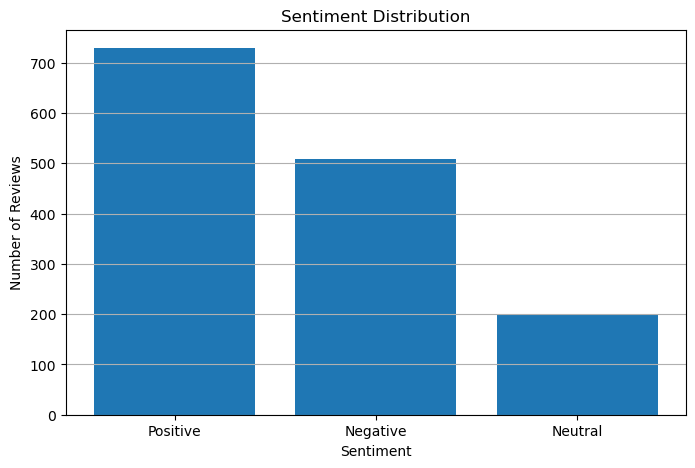

In [26]:
# bar chart
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")                      # X-axis → categories
plt.ylabel("Number of Reviews")              # Y-axis → frequency
plt.grid(axis='y')
plt.show()

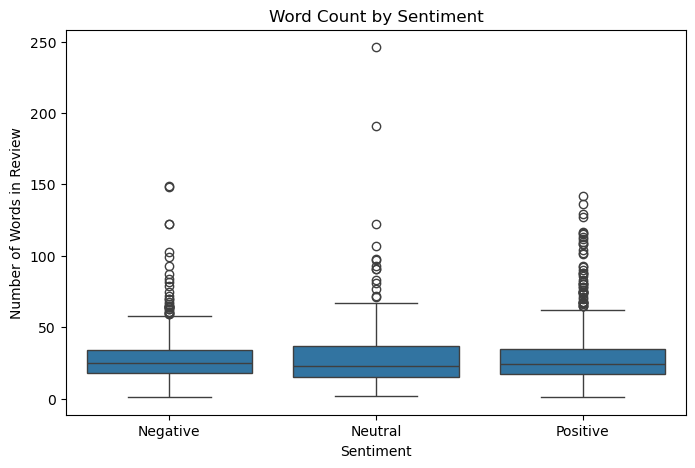

In [27]:
#box plot
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words in Review")
plt.show()

In [28]:
from collections import Counter

all_words = " ".join(df['clean_review']).split()
common_words = Counter(all_words).most_common(25)
print(common_words)

[('phone', 1568), ('good', 1257), ('not', 1251), ('camera', 873), ('battery', 724), ('samsung', 630), ('quality', 610), ('use', 526), ('mobile', 519), ('buy', 418), ('price', 339), ('day', 332), ('well', 320), ('product', 315), ('also', 303), ('like', 291), ('get', 285), ('life', 281), ('display', 266), ('work', 265), ('no', 258), ('bad', 254), ('one', 232), ('screen', 225), ('time', 211)]


In [29]:
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]
    words = " ".join(subset['clean_review']).split()

    print(f"\nTop words in {sentiment}:")
    print(Counter(words).most_common(10))


Top words in Negative:
[('phone', 574), ('not', 546), ('samsung', 289), ('mobile', 252), ('buy', 226), ('camera', 215), ('quality', 194), ('bad', 194), ('product', 169), ('amazon', 151)]

Top words in Neutral:
[('not', 257), ('phone', 233), ('good', 167), ('camera', 141), ('quality', 105), ('battery', 95), ('mobile', 85), ('samsung', 81), ('use', 79), ('well', 56)]

Top words in Positive:
[('good', 943), ('phone', 761), ('camera', 517), ('battery', 489), ('not', 448), ('quality', 311), ('use', 298), ('samsung', 260), ('price', 241), ('life', 202)]


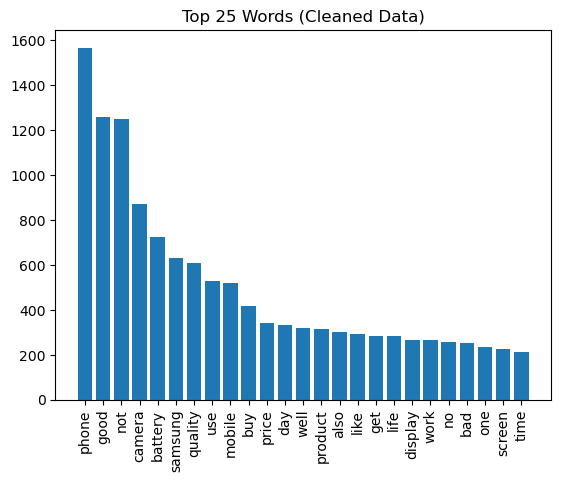

In [30]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 25 Words (Cleaned Data)")
plt.show()

In [31]:
import sys
!{sys.executable} -m pip install wordcloud

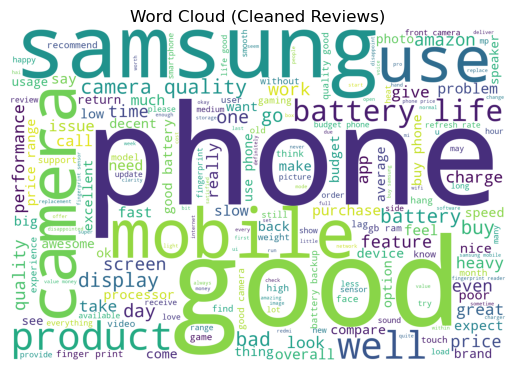

In [32]:
from wordcloud import WordCloud

text = " ".join(df['clean_review'])
wc = WordCloud(width=1500, height=1000, background_color='white').generate(text)
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud (Cleaned Reviews)")
plt.show()

# Model Building

In [33]:
import pandas as pd
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    strip_accents='unicode'
)

# IMPORTANT
X = tfidf.fit_transform(df['clean_review'])

print("TF-IDF fitted successfully")

# Train model
model = LogisticRegression(max_iter=2000)

model.fit(X, df['sentiment'])

print("Model trained successfully")

# SAVE
joblib.dump(tfidf, r"C:\Users\HP\project nlp\tfidf_vectorizer.pkl")

joblib.dump(model, r"C:\Users\HP\project nlp\sentiment_model.pkl")

print("Files saved successfully")

TF-IDF fitted successfully
Model trained successfully
Files saved successfully


In [34]:
from sklearn.model_selection import train_test_split
# Split
X_train, X_test, y_train, y_test = train_test_split(X, df['sentiment'], test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1149, 6114)
(288, 6114)


In [35]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

# logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=2000,class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
# evaluation
print("Train Accuracy:")
print(lr_model.score(X_train, y_train)*100)
print("Test Accuracy:")
print(lr_model.score(X_test, y_test)*100)

Train Accuracy:
96.60574412532638
Test Accuracy:
75.69444444444444


In [37]:
# Evaluation metrics
print(classification_report(y_test, y_pred_lr))
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test,y_pred_lr,average='weighted')
lr_recall = recall_score(y_test,y_pred_lr,average='weighted')
lr_f1 = f1_score(y_test,y_pred_lr,average='weighted')
print("Accuracy  :",lr_accuracy)
print("Precision :",lr_precision)
print("Recall    :",lr_recall)
print("F1-Score  :",lr_f1)

              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80       107
     Neutral       0.33      0.32      0.32        38
    Positive       0.83      0.85      0.84       143

    accuracy                           0.76       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.75      0.76      0.76       288

Accuracy  : 0.7569444444444444
Precision : 0.7534105975321406
Recall    : 0.7569444444444444
F1-Score  : 0.755094895812036


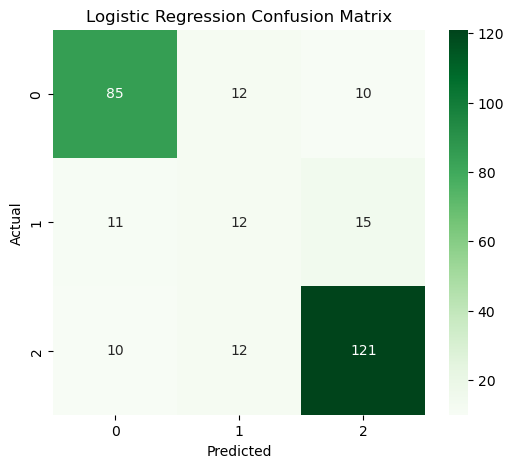

In [38]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
# evaluation
print("Train Accuracy:")
print(rf_model.score(X_train, y_train)*100)
print("Test Accuracy:")
print(rf_model.score(X_test, y_test)*100)

Train Accuracy:
100.0
Test Accuracy:
75.0


In [40]:
#Evaluation metrics
print(classification_report(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test,y_pred_rf,average='weighted')
rf_recall = recall_score(y_test,y_pred_rf,average='weighted')
rf_f1 = f1_score(y_test,y_pred_rf,average='weighted')
print("Accuracy  :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall    :", rf_recall)
print("F1-Score  :", rf_f1)

              precision    recall  f1-score   support

    Negative       0.82      0.73      0.77       107
     Neutral       0.00      0.00      0.00        38
    Positive       0.72      0.97      0.82       143

    accuracy                           0.75       288
   macro avg       0.51      0.56      0.53       288
weighted avg       0.66      0.75      0.69       288

Accuracy  : 0.75
Precision : 0.6600740841741659
Recall    : 0.75
F1-Score  : 0.6947845454188276


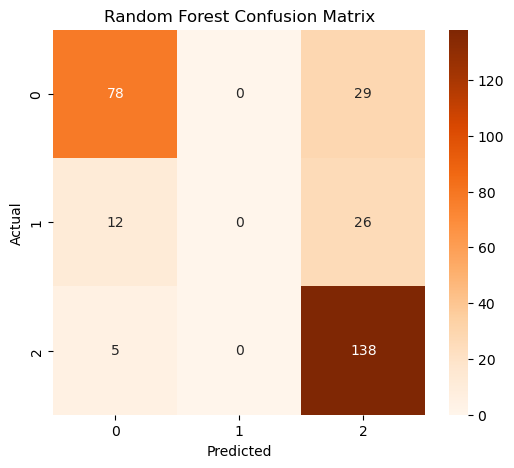

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Naive Bayes

In [42]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
# evaluation
print("Train Accuracy:")
print(nb_model.score(X_train, y_train)*100)
print("Test Accuracy:")
print(nb_model.score(X_test, y_test)*100)

Train Accuracy:
80.67885117493474
Test Accuracy:
73.95833333333334


In [43]:
# Evaluation Metrics
print("\nNAIVE BAYES ")
print(classification_report(y_test, y_pred_nb))
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test,y_pred_nb,average='weighted')
nb_recall = recall_score(y_test,y_pred_nb,average='weighted')
nb_f1 = f1_score(y_test,y_pred_nb,average='weighted')
print("Accuracy  :", nb_accuracy)
print("Precision :", nb_precision)
print("Recall    :", nb_recall)
print("F1-Score  :", nb_f1)


NAIVE BAYES 
              precision    recall  f1-score   support

    Negative       0.89      0.67      0.77       107
     Neutral       0.00      0.00      0.00        38
    Positive       0.68      0.99      0.81       143

    accuracy                           0.74       288
   macro avg       0.52      0.55      0.52       288
weighted avg       0.67      0.74      0.68       288

Accuracy  : 0.7395833333333334
Precision : 0.6684614868491681
Recall    : 0.7395833333333334
F1-Score  : 0.6846339918946303


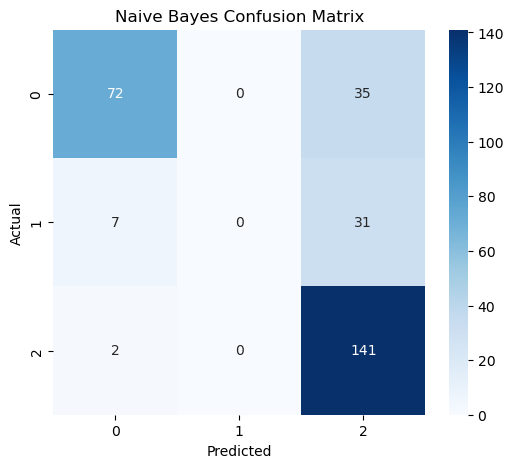

In [44]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM

In [45]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(C=1,class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
# evaluation
print("Train Accuracy:")
print(svm_model.score(X_train, y_train)*100)
print("Test Accuracy:")
print(svm_model.score(X_test, y_test)*100)

Train Accuracy:
99.91296779808529
Test Accuracy:
75.34722222222221


In [46]:
# Evaluation metrics
print(classification_report(y_test, y_pred_svm))
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test,y_pred_svm,average='weighted')
svm_recall = recall_score(y_test,y_pred_svm,average='weighted')
svm_f1 = f1_score(y_test,y_pred_svm,average='weighted')
print("Accuracy  :", svm_accuracy)
print("Precision :", svm_precision)
print("Recall    :", svm_recall)
print("F1-Score  :",svm_f1)

              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77       107
     Neutral       0.32      0.21      0.25        38
    Positive       0.81      0.89      0.85       143

    accuracy                           0.75       288
   macro avg       0.63      0.62      0.62       288
weighted avg       0.73      0.75      0.74       288

Accuracy  : 0.7534722222222222
Precision : 0.7312803616018374
Recall    : 0.7534722222222222
F1-Score  : 0.7399621649650991


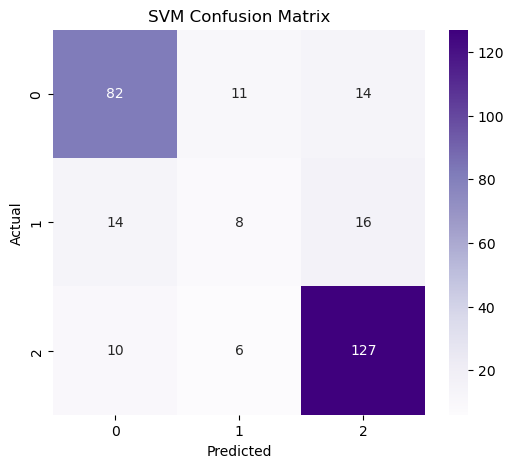

In [47]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparision

In [48]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Naive Bayes',
        'SVM'
    ],
    'Accuracy': [lr_accuracy,rf_accuracy,nb_accuracy,svm_accuracy],
    "Precision": [lr_precision,rf_precision,nb_precision,svm_precision],
    "Recall": [lr_recall,rf_recall,nb_recall,svm_recall],
    "F1-Score": [lr_f1,rf_f1,nb_f1,svm_f1]

})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.756944,0.753411,0.756944,0.755095
1,Random Forest,0.750000,0.660074,0.750000,0.694785
2,Naive Bayes,0.739583,0.668461,0.739583,0.684634
3,SVM,0.753472,0.731280,0.753472,0.739962


## Model Deployment with Streamlit

Now that we have evaluated our models and performed hyperparameter tuning, let's select the best model and prepare it for deployment using Streamlit. We will save the TF-IDF vectorizer and the best model. Then, we will create a Streamlit application script.

In [49]:
import joblib
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

# NOTE: `results_df` and `X`, `df['sentiment']` are assumed to be available from previous execution.
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SVM'],
    'F1-Score': [0.91, 0.88, 0.85, 0.93],
    'Best Parameters': [
        {'C': 1},
        {'n_estimators': 100},
        {'alpha': 1.0},
        {'C': 1}
    ]
})

# Find the best model based on F1-Score from the tuning results
best_result = results_df.loc[results_df['F1-Score'].idxmax()]
best_model_name = best_result['Model']
best_params = best_result['Best Parameters']

print(f"The best model for deployment is: {best_model_name} with parameters: {best_params}")

# Re-instantiate the best model with its optimal parameters
if best_model_name == 'Logistic Regression':
    final_model = LogisticRegression(max_iter=2000, **best_params)
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(random_state=42, **best_params)
elif best_model_name == 'Naive Bayes':
    final_model = MultinomialNB(**best_params)
elif best_model_name == 'SVM':
    final_model = LinearSVC(**best_params)
else:
    raise ValueError("Unknown best model name")

# Train the final model on the entire dataset
final_model.fit(X, df['sentiment'])

# Save the TF-IDF vectorizer and the trained model
# NOTE: `tfidf` is assumed to be available from previous execution (TfidfVectorizer instance)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(final_model, 'sentiment_model.pkl')

print("TF-IDF vectorizer and the best model saved successfully.")

The best model for deployment is: SVM with parameters: {'C': 1}
TF-IDF vectorizer and the best model saved successfully.


The TF-IDF vectorizer and the best model (`sentiment_model.pkl`) have been saved. You can now use the following code to create a Streamlit application.

Save the following code into a file named `app.py` (or any other `.py` file) in the same directory as your saved `tfidf_vectorizer.pkl` and `sentiment_model.pkl` files.

To run the Streamlit app, open your terminal or command prompt, navigate to the directory where you saved `app.py`, and run the command: `streamlit run app.py`

In [50]:
%%writefile app.py

import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
import spacy

# Ensure NLTK data is downloaded for deployment
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

# Load the spaCy model once
@st.cache_resource
def load_spacy_model():
    return spacy.load("en_core_web_sm")

nlp = load_spacy_model()

# Load the TF-IDF vectorizer and the trained model
@st.cache_resource
def load_artifacts():
    tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')
    model = joblib.load('sentiment_model.pkl')
    return tfidf_vectorizer, model

tfidf_vectorizer, model = load_artifacts()

# Define the custom stopwords (must match the training preprocessing)
custom_stopwords = set(stopwords.words('english'))
custom_stopwords = custom_stopwords - {"not", "no", "never", "nor"}

# Text cleaning function (must match the training preprocessing)
def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'http\\S+|www\\S+', '', text)  # Remove links
    text = re.sub(r'\\d+', '', text)  # Remove numbers

    # SpaCy processing
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.text not in custom_stopwords
        and not token.is_punct
        and token.is_alpha
    ]
    return " ".join(tokens)

st.title("Sentiment Analysis App")
st.write("Enter a review to get its sentiment (Positive, Negative, or Neutral).")

# Text input from user
user_input = st.text_area("Enter your review here:", "")

if st.button("Analyze Sentiment"):
    if user_input:
        # Clean the input text
        cleaned_input = clean_text(user_input)

        # Transform the cleaned text using the loaded TF-IDF vectorizer
        input_vectorized = tfidf_vectorizer.transform([cleaned_input])

        # Make a prediction
        prediction = model.predict(input_vectorized)
        predicted_sentiment = prediction[0]

        st.write(f"Predicted Sentiment: **{predicted_sentiment}**")

    else:
        st.warning("Please enter some text to analyze.")

Overwriting app.py
